# **DATASET**

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import seaborn as sns
import itertools

In [2]:
# DOWNLOAD DATA YAHOO FINANCE
tickers = {
    'USD_IDR': 'IDR=X',       # Target Prediksi
    'DXY': 'DX-Y.NYB',        # Indeks Kekuatan US Dollar Global
    'IHSG': '^JKSE',          # Sentimen Pasar Saham Domestik
    'Emas': 'GC=F',           # Harga Emas Global (Safe Haven)
    'Minyak': 'CL=F'          # Harga Minyak Mentah Dunia (WTI Crude Oil)
}

# 5 tahun ke belakang
data_raw = yf.download(
    list(tickers.values()),
    start="2021-01-01",
    end="2026-05-28",
    interval="1d"
)
df = data_raw['Close'].copy().rename(columns={v: k for k, v in tickers.items()})

# Cleaning
df = df.ffill().bfill().reset_index()
df['Date'] = df['Date'].dt.tz_localize(None)

/tmp/ipykernel_2540/639917901.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(
[*********************100%***********************]  5 of 5 completed


In [3]:
# Simpan dataframe ke file Excel
df.to_excel("Data_Market_YahooFinance.xlsx", index=False)

print("Data berhasil disimpan ke Data_Market_YahooFinance.xlsx")

Data berhasil disimpan ke Data_Market_YahooFinance.xlsx


In [4]:
df.head()

Ticker,Date,Minyak,DXY,Emas,USD_IDR,IHSG
0,2021-01-01,47.619999,89.879997,1944.699951,13932.374023,6104.897949
1,2021-01-04,47.619999,89.879997,1944.699951,14022.500977,6104.897949
2,2021-01-05,49.930000,89.440002,1952.699951,13931.400391,6137.342773
3,2021-01-06,50.630001,89.529999,1906.900024,13930.000000,6065.682129
4,2021-01-07,50.830002,89.830002,1912.300049,13951.500000,6153.632812


In [5]:
df.describe()

Ticker,Date,Minyak,DXY,Emas,USD_IDR,IHSG
count,1405,1405.000000,1405.000000,1405.000000,1405.000000,1405.000000
mean,2023-09-12 11:00:02.562277632,76.613737,100.807530,2458.553306,15458.777159,7005.122415
min,2021-01-01 00:00:00,47.619999,89.440002,1623.300049,13828.136719,5760.583984
25%,2022-05-09 00:00:00,67.379997,97.709999,1820.900024,14584.200195,6661.878906
50%,2023-09-12 00:00:00,74.370003,101.750000,1980.699951,15468.000000,6956.804199
75%,2025-01-16 00:00:00,82.820000,104.449997,2744.300049,16246.000000,7238.785156
max,2026-05-27 00:00:00,123.699997,114.110001,5318.399902,17777.000000,9134.700195
std,NaN,13.527885,5.276425,921.504186,900.908148,614.028426


In [6]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1405 entries, 0 to 1404
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     1405 non-null   datetime64[ns]
 1   Minyak   1405 non-null   float64       
 2   DXY      1405 non-null   float64       
 3   Emas     1405 non-null   float64       
 4   USD_IDR  1405 non-null   float64       
 5   IHSG     1405 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 66.0 KB


(1405, 6)

In [7]:
df.isnull().sum()

,0
Ticker,
Date,0
Minyak,0
DXY,0
Emas,0
USD_IDR,0
IHSG,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# 3.1 Info tipe data & pengecekan nilai kosong / duplikat
print(df.info())
print("\nJumlah missing value per kolom:\n", df.isna().sum())
print("\nJumlah tanggal duplikat:", df["Date"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1405 entries, 0 to 1404
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     1405 non-null   datetime64[ns]
 1   Minyak   1405 non-null   float64       
 2   DXY      1405 non-null   float64       
 3   Emas     1405 non-null   float64       
 4   USD_IDR  1405 non-null   float64       
 5   IHSG     1405 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 66.0 KB
None

Jumlah missing value per kolom:
 Ticker
Date       0
Minyak     0
DXY        0
Emas       0
USD_IDR    0
IHSG       0
dtype: int64

Jumlah tanggal duplikat: 0


## Penyamaan Frekuensi Data (Business Day) & Pengisian Tanggal yang Hilang

Mengisi 4 tanggal yang hilang yaitu


*   1 Januari 2025
*   18 April 2025
*   25 Desember 2025
*   1 Januari 2026







In [10]:
# Urutkan berdasarkan tanggal & jadikan Date sebagai index waktu
df = df.sort_values("Date").reset_index(drop=True)
df.set_index("Date", inplace=True)

In [11]:
# Samakan ke frekuensi hari bursa (Business day) agar index memiliki frekuensi eksplisit
# dibutuhkan agar ARIMA (statsmodels) dapat mengindeks hasil forecast dengan benar.
df = df.asfreq("B")
print("Missing value setelah disamakan ke frekuensi 'B' (hari libur bursa akan muncul sbg NaN):")
print(df.isna().sum())

# Isi hari libur bursa dengan nilai perdagangan terakhir (forward-fill),
# pendekatan standar untuk data pasar keuangan.
df = df.ffill()
print("\nMissing value setelah forward-fill:\n", df.isna().sum())

print(f"\nRentang data: {df.index.min().date()} s/d {df.index.max().date()}  ({len(df)} observasi)")
df.describe().T

Missing value setelah disamakan ke frekuensi 'B' (hari libur bursa akan muncul sbg NaN):
Ticker
Minyak     4
DXY        4
Emas       4
USD_IDR    4
IHSG       4
dtype: int64

Missing value setelah forward-fill:
 Ticker
Minyak     0
DXY        0
Emas       0
USD_IDR    0
IHSG       0
dtype: int64

Rentang data: 2021-01-01 s/d 2026-05-27  (1409 observasi)


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
Minyak,1409.0,76.575209,13.531408,47.619999,67.330002,74.300003,82.809998,123.699997
DXY,1409.0,100.808169,5.274007,89.440002,97.720001,101.750000,104.449997,114.110001
Emas,1409.0,2462.037966,923.395386,1623.300049,1821.199951,1981.599976,2755.000000,5318.399902
USD_IDR,1409.0,15461.963171,901.738795,13828.136719,14597.000000,15473.900391,16247.799805,17777.000000
IHSG,1409.0,7007.026272,616.255995,5760.583984,6661.878906,6956.804199,7240.276855,9134.700195


# **EDA**

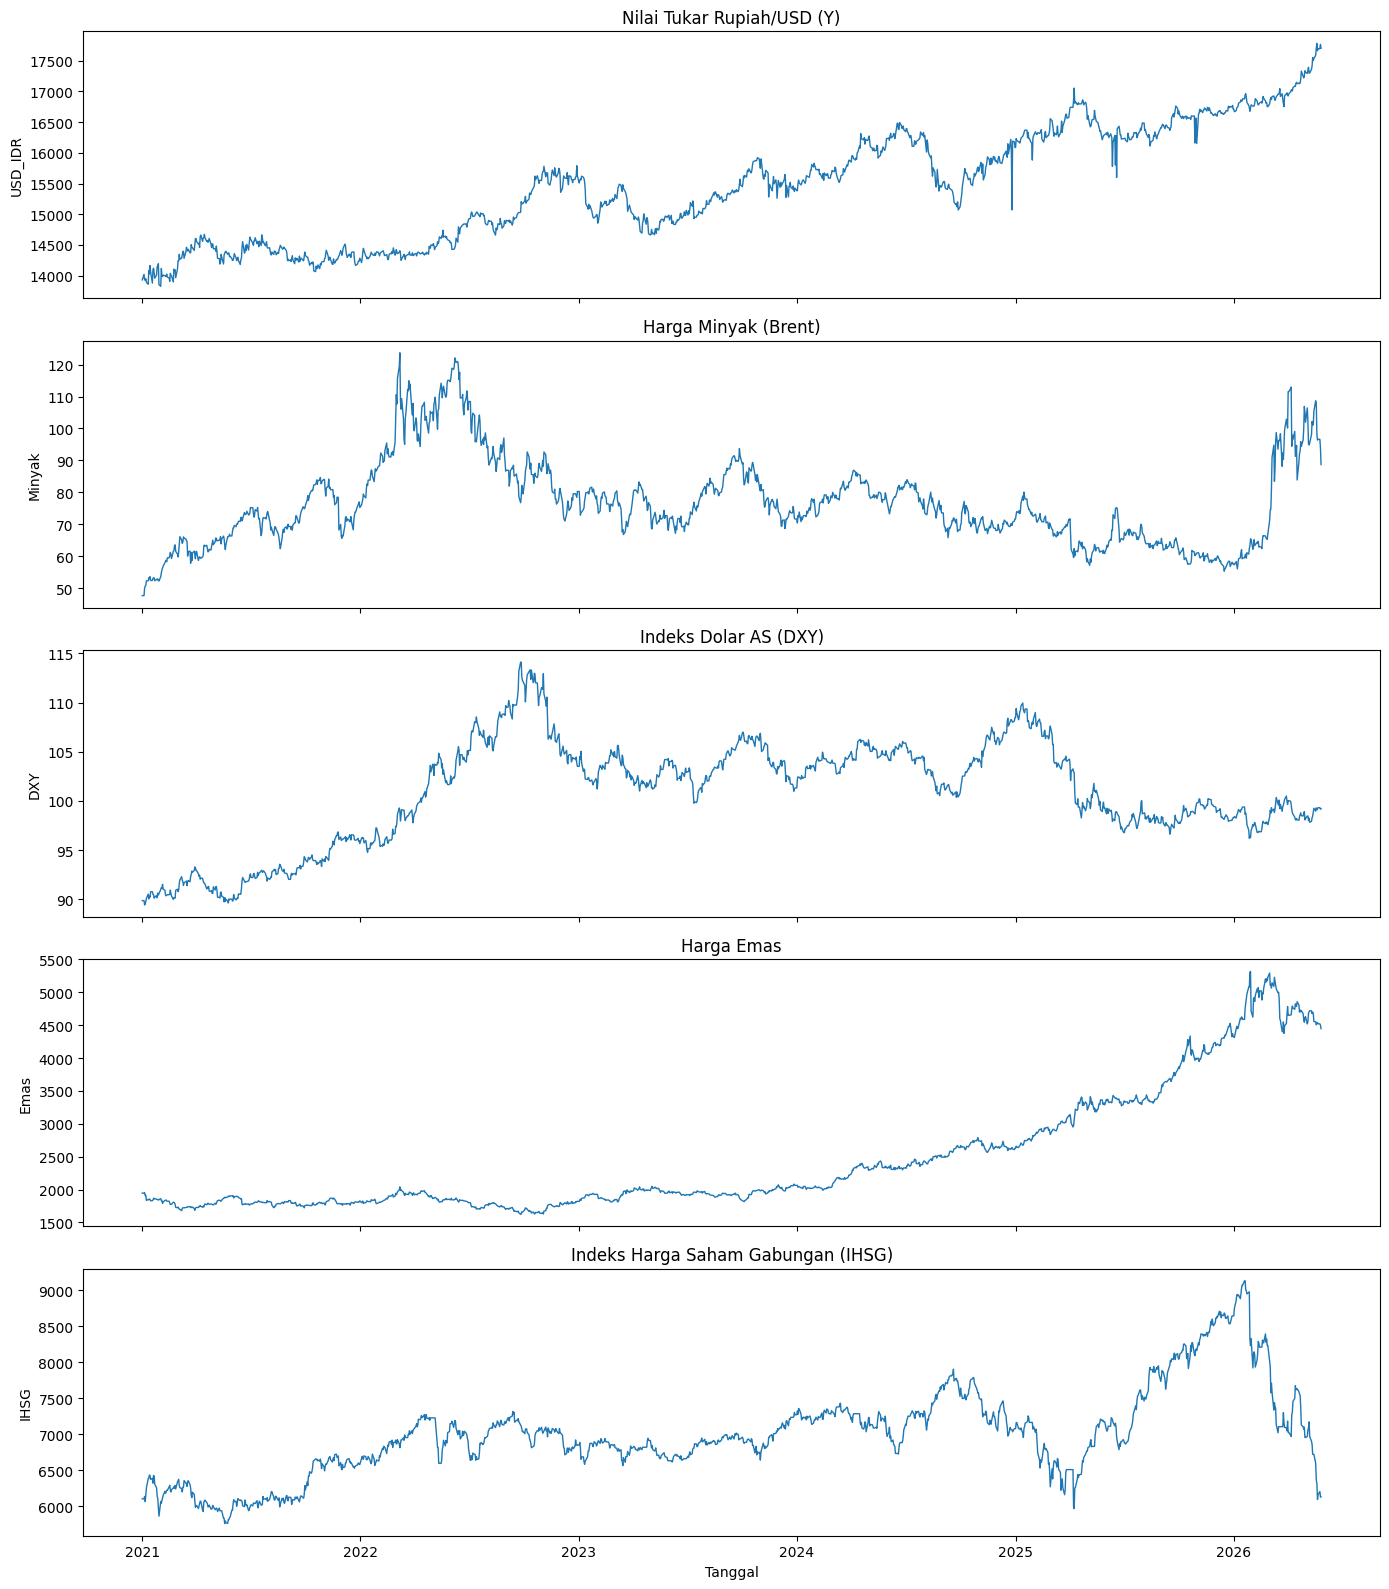

In [12]:
# Visualisasi seluruh variabel
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
cols = ["USD_IDR", "Minyak", "DXY", "Emas", "IHSG"]
titles = ["Nilai Tukar Rupiah/USD (Y)", "Harga Minyak (Brent)", "Indeks Dolar AS (DXY)",
          "Harga Emas", "Indeks Harga Saham Gabungan (IHSG)"]
for ax, col, title in zip(axes, cols, titles):
    ax.plot(df.index, df[col], linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(col)
plt.xlabel("Tanggal")
plt.tight_layout()
plt.show()

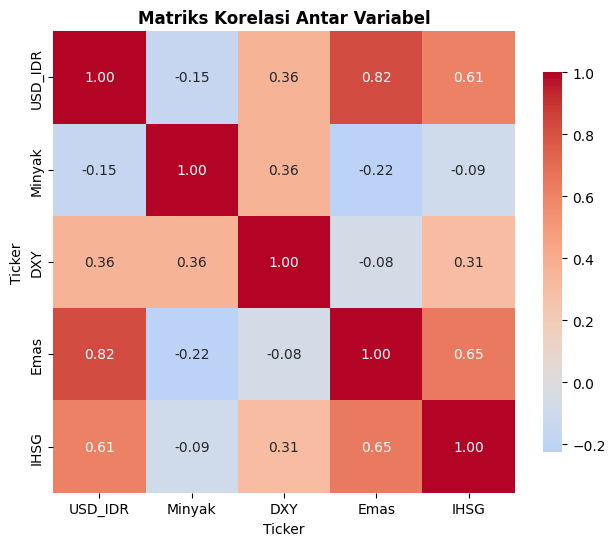

Korelasi terhadap USD_IDR (diurutkan):
Ticker
USD_IDR    1.000000
Emas       0.820698
IHSG       0.609443
DXY        0.363050
Minyak    -0.153977
Name: USD_IDR, dtype: float64


In [13]:
plt.figure(figsize=(6.5, 5.5))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Antar Variabel', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Korelasi terhadap USD_IDR (diurutkan):")
print(corr['USD_IDR'].sort_values(ascending=False))

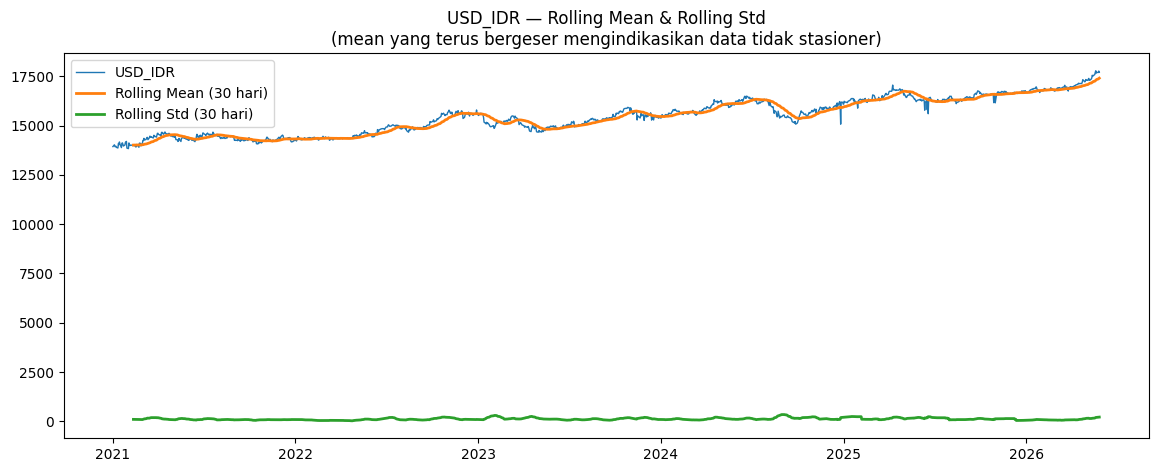

In [14]:
# Rolling mean & rolling std pada USD_IDR -- indikasi visual (non-)stasioneritas
window = 30
roll_mean = df["USD_IDR"].rolling(window).mean()
roll_std = df["USD_IDR"].rolling(window).std()

plt.figure(figsize=(14, 5))
plt.plot(df["USD_IDR"], label="USD_IDR", linewidth=1)
plt.plot(roll_mean, label=f"Rolling Mean ({window} hari)", linewidth=2)
plt.plot(roll_std, label=f"Rolling Std ({window} hari)", linewidth=2)
plt.legend()
plt.title("USD_IDR — Rolling Mean & Rolling Std\n(mean yang terus bergeser mengindikasikan data tidak stasioner)")
plt.show()

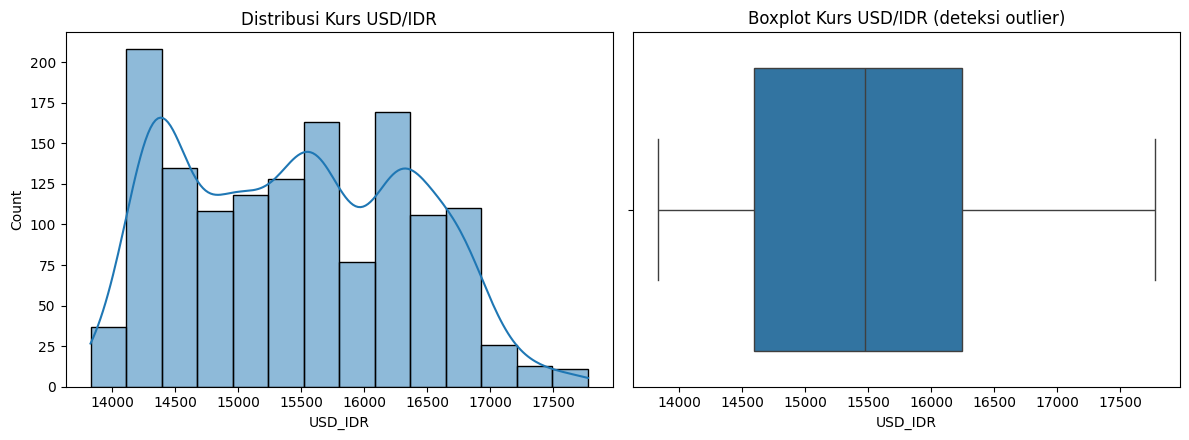

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['USD_IDR'], kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribusi Kurs USD/IDR')
sns.boxplot(x=df['USD_IDR'], ax=axes[1], color='#1f77b4')
axes[1].set_title('Boxplot Kurs USD/IDR (deteksi outlier)')
plt.tight_layout()
plt.show()

## Pembagian Data (Train-Test Split)

In [16]:
target = "USD_IDR"
n = len(df)
train_size = int(n * 0.80)

train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Data latih : {train.index.min().date()} s/d {train.index.max().date()}  ({len(train)} observasi)")
print(f"Data uji   : {test.index.min().date()} s/d {test.index.max().date()}  ({len(test)} observasi)")

Data latih : 2021-01-01 s/d 2025-04-28  (1127 observasi)
Data uji   : 2025-04-29 s/d 2026-05-27  (282 observasi)


## Uji Stasioneritas — Augmented Dickey-Fuller (ADF)

In [17]:
def adf_report(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "Variabel": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lag digunakan": result[2],
        "Kesimpulan (alpha=10%)": "Stasioner" if result[1] < 0.10 else "Tidak Stasioner"
    }

y_train = train[target]

adf_table = pd.DataFrame([
    adf_report(y_train, "Level"),
    adf_report(y_train.diff(), "Differencing ke-1"),
    adf_report(y_train.diff().diff(), "Differencing ke-2"),
])
adf_table

,Variabel,ADF Statistic,p-value,Lag digunakan,Kesimpulan (alpha=10%)
0,Level,-0.704823,8.454964e-01,4,Tidak Stasioner
1,Differencing ke-1,-25.367109,0.000000e+00,2,Stasioner
2,Differencing ke-2,-12.469111,3.274912e-23,22,Stasioner


# **Model ARIMA**

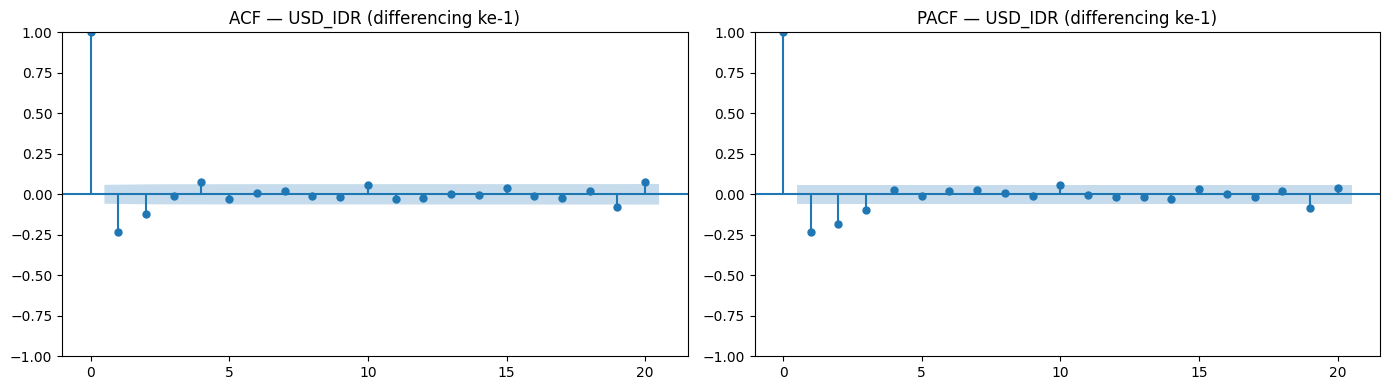

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

d = 1
y_diff = y_train.diff(d).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff, lags=20, ax=axes[0])
axes[0].set_title(f"ACF — USD_IDR (differencing ke-{d})")
plot_pacf(y_diff, lags=20, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF — USD_IDR (differencing ke-{d})")
plt.tight_layout()
plt.show()

**Cara membaca plot:** orde `p` (AR) dilihat dari lag terakhir PACF yang signifikan (keluar dari
pita biru), orde `q` (MA) dilihat dari lag terakhir ACF yang signifikan. Sebagai pelengkap sekaligus
validasi silang, sel berikut melakukan **grid search** kandidat model ARIMA di sekitar orde yang
teridentifikasi, lalu memilih model terbaik berdasarkan MAPE pada data testing.

## Penentuan Parameter & Model ARIMA Terbaik

In [19]:
p_range = range(0, 4)
q_range = range(0, 4)
d_candidates = sorted(set([d, 1, 2]))   # sertakan d hasil ADF + 1 & 2 sebagai pembanding

results = []
for d_ in d_candidates:
    for p_, q_ in itertools.product(p_range, q_range):
        if p_ == 0 and q_ == 0:
            continue
        try:
            fitted = ARIMA(y_train, order=(p_, d_, q_)).fit()
            fc = fitted.forecast(steps=len(test))
            mape_val = mean_absolute_percentage_error(test[target], fc) * 100
            results.append({"order": (p_, d_, q_), "AIC": fitted.aic, "MAPE_test(%)": mape_val})
        except Exception:
            continue

arima_results = pd.DataFrame(results).sort_values("MAPE_test(%)").reset_index(drop=True)
arima_results.head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: Us

,order,AIC,MAPE_test(%)
0,"(1, 1, 0)",13155.386611,1.868632
1,"(0, 1, 1)",13126.128720,1.871073
2,"(2, 1, 0)",13118.287613,1.876812
3,"(3, 1, 3)",13112.829209,1.877102
4,"(1, 1, 1)",13117.905398,1.877623
5,"(0, 1, 3)",13115.388417,1.879707
6,"(1, 1, 2)",13115.992600,1.879967
7,"(0, 1, 2)",13114.389471,1.880198
8,"(2, 1, 1)",13113.229430,1.881513
9,"(2, 1, 3)",13112.289864,1.881674


In [20]:
best_order = arima_results.iloc[0]["order"]
print("Model ARIMA terbaik berdasarkan MAPE data testing: ARIMA", best_order)

best_arima = ARIMA(y_train, order=best_order).fit()
print(best_arima.summary())

Model ARIMA terbaik berdasarkan MAPE data testing: ARIMA (1, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                USD_IDR   No. Observations:                 1127
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -6575.693
Date:                Mon, 17 Aug 2026   AIC                          13155.387
Time:                        09:20:32   BIC                          13165.439
Sample:                    01-01-2021   HQIC                         13159.185
                         - 04-28-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2314      0.008    -28.852      0.000      -0.247      -0.216
sigma2      6912.8209     79.693     86.743      0.000    6756.6

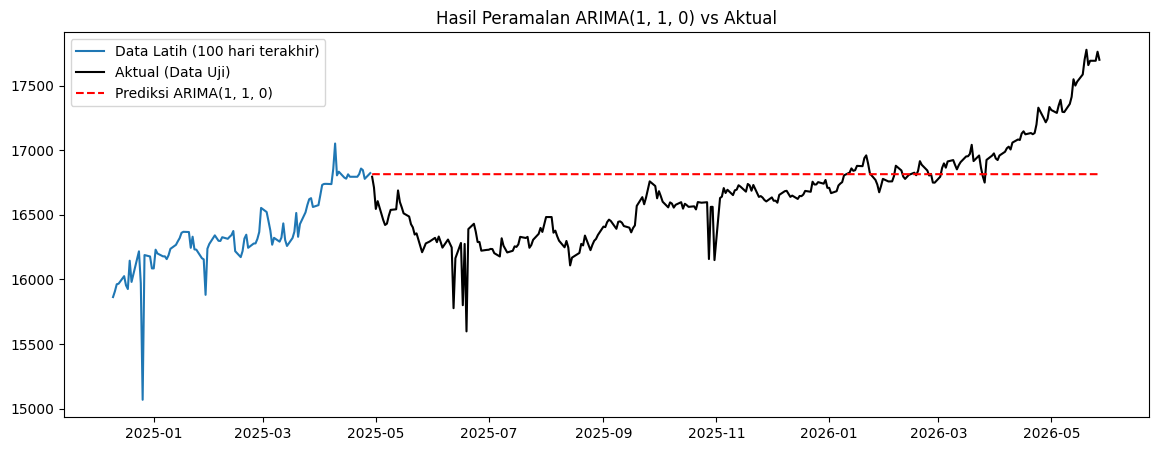

MAPE : 1.87%
RMSE : 388.17
MAE  : 310.20


In [21]:
arima_forecast = best_arima.forecast(steps=len(test))
arima_forecast.index = test.index

plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], y_train[-100:], label="Data Latih (100 hari terakhir)")
plt.plot(test.index, test[target], label="Aktual (Data Uji)", color="black")
plt.plot(test.index, arima_forecast, label=f"Prediksi ARIMA{best_order}", color="red", linestyle="--")
plt.legend()
plt.title(f"Hasil Peramalan ARIMA{best_order} vs Aktual")
plt.show()

arima_mape = mean_absolute_percentage_error(test[target], arima_forecast) * 100
arima_rmse = float(np.sqrt(mean_squared_error(test[target], arima_forecast)))
arima_mae = float(mean_absolute_error(test[target], arima_forecast))
print(f"MAPE : {arima_mape:.2f}%")
print(f"RMSE : {arima_rmse:,.2f}")
print(f"MAE  : {arima_mae:,.2f}")

## Uji Kelayakan Model ARIMA Terbaik

- **Uji white noise**: plot ACF residual (tidak ada lag signifikan → tidak ada autokorelasi sisaan)
  serta uji formal Ljung-Box.
- **Uji normalitas**: histogram residual (pola lonceng) serta uji formal Jarque-Bera.

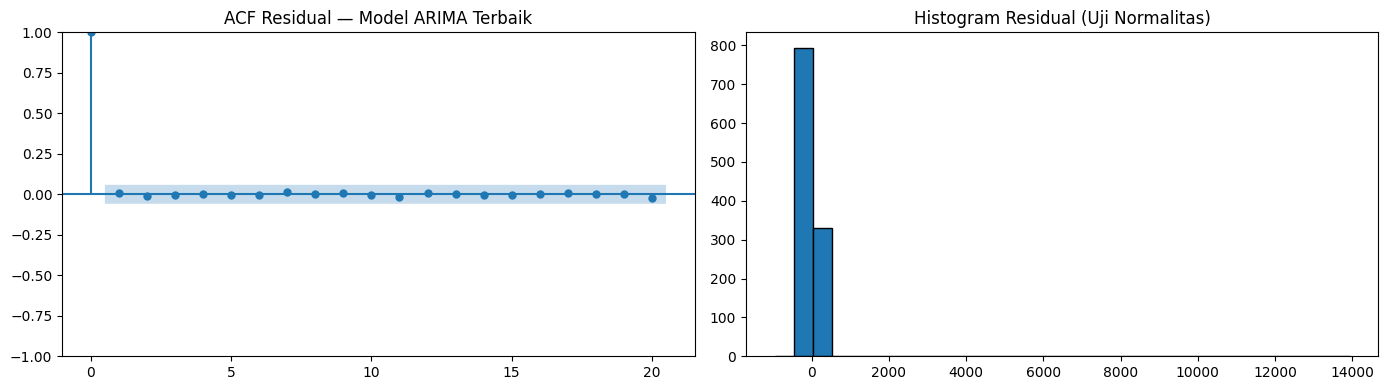

Uji Ljung-Box (H0: residual white noise / tidak ada autokorelasi):
      lb_stat  lb_pvalue
10  0.642194   0.999978
20  1.704289   1.000000

Uji Jarque-Bera (H0: residual berdistribusi normal): statistik=50677543.59, p-value=0.0000


In [22]:
residuals = best_arima.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=20, ax=axes[0])
axes[0].set_title("ACF Residual — Model ARIMA Terbaik")
axes[1].hist(residuals, bins=30, edgecolor="black")
axes[1].set_title("Histogram Residual (Uji Normalitas)")
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("Uji Ljung-Box (H0: residual white noise / tidak ada autokorelasi):\n", lb_test)

jb_stat, jb_p, skew, kurt = jarque_bera(residuals)
print(f"\nUji Jarque-Bera (H0: residual berdistribusi normal): "
      f"statistik={jb_stat:.2f}, p-value={jb_p:.4f}")

# **Model LSTM**

Agar perbandingan dengan ARIMA adil (apples-to-apples), LSTM tahap ini **hanya menggunakan riwayat
USD_IDR itu sendiri** sebagai input (univariat), sama seperti informasi yang dipakai ARIMA.
Model LSTM multivariat (dengan variabel Minyak, DXY, Emas, IHSG) tidak saya gunakan.

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [24]:
LOOKBACK = 30   # jumlah hari historis yang "dilihat" model untuk memprediksi 1 hari ke depan

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[[target]])
full_scaled = scaler.transform(df[[target]])

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train_lstm = create_sequences(train_scaled, LOOKBACK)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# Sertakan LOOKBACK hari terakhir data latih sebagai konteks awal utk memprediksi hari pertama data uji
test_input = full_scaled[train_size - LOOKBACK:]
X_test, y_test_lstm = create_sequences(test_input, LOOKBACK)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Shape X_train:", X_train.shape, " | Shape X_test:", X_test.shape)

Shape X_train: (1097, 30, 1)  | Shape X_test: (282, 30, 1)


## Membangun & Melatih Model LSTM

In [25]:
tf.random.set_seed(SEED)

model_lstm = Sequential([
    LSTM(64, activation="tanh", return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0341 - val_loss: 0.0081
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0055 - val_loss: 0.0029
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0046 - val_loss: 0.0040
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0039 - val_loss: 0.0022
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0040 - val_loss: 0.0020
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0039 - val_loss: 0.0022
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0035 - val_loss: 0.0027
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0036 - val_loss: 0.0021
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0033 - val_loss: 0.0021
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0028 - val_loss: 0.0020
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

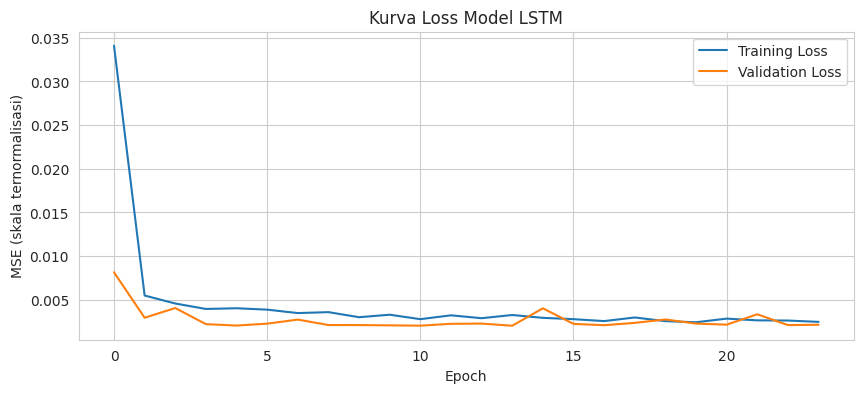

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Kurva Loss Model LSTM")
plt.xlabel("Epoch")
plt.ylabel("MSE (skala ternormalisasi)")
plt.show()

## Evaluasi Model LSTM

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


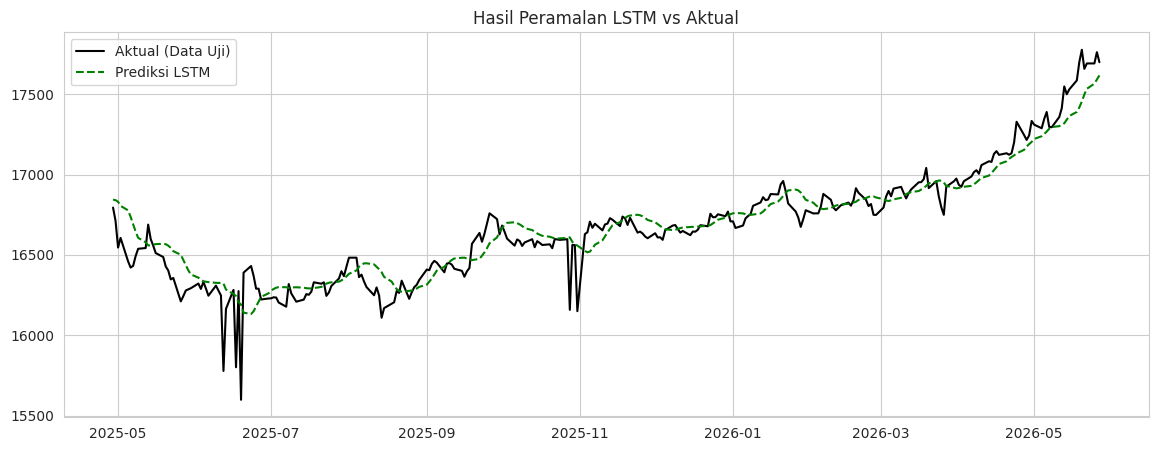

MAPE : 0.52%
RMSE : 120.75
MAE  : 85.58


In [28]:
y_pred_scaled = model_lstm.predict(X_test)
y_pred_lstm = scaler.inverse_transform(y_pred_scaled).flatten()
y_true_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 5))
plt.plot(test.index[:len(y_pred_lstm)], y_true_lstm, label="Aktual (Data Uji)", color="black")
plt.plot(test.index[:len(y_pred_lstm)], y_pred_lstm, label="Prediksi LSTM", color="green", linestyle="--")
plt.legend()
plt.title("Hasil Peramalan LSTM vs Aktual")
plt.show()

lstm_mape = mean_absolute_percentage_error(y_true_lstm, y_pred_lstm) * 100
lstm_rmse = float(np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm)))
lstm_mae = float(mean_absolute_error(y_true_lstm, y_pred_lstm))
print(f"MAPE : {lstm_mape:.2f}%")
print(f"RMSE : {lstm_rmse:,.2f}")
print(f"MAE  : {lstm_mae:,.2f}")

# **ARIMA vs LSTM**

In [29]:
comparison = pd.DataFrame({
    "Model": [f"ARIMA{best_order}", "LSTM (univariat)"],
    "MAPE (%)": [arima_mape, lstm_mape],
    "RMSE": [arima_rmse, lstm_rmse],
    "MAE": [arima_mae, lstm_mae],
}).sort_values("MAPE (%)").reset_index(drop=True)
comparison

,Model,MAPE (%),RMSE,MAE
0,LSTM (univariat),0.515501,120.752279,85.583004
1,"ARIMA(1, 1, 0)",1.868632,388.169295,310.196184


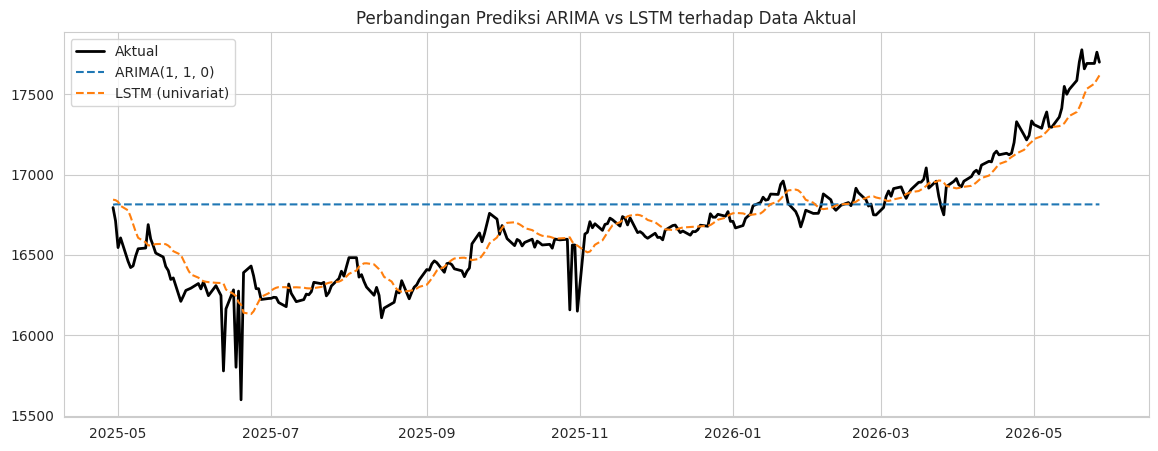

Model dengan MAPE terkecil (data uji): LSTM (univariat) (0.52%)


In [30]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test[target], label="Aktual", color="black", linewidth=2)
plt.plot(test.index, arima_forecast, label=f"ARIMA{best_order}", linestyle="--")
plt.plot(test.index[:len(y_pred_lstm)], y_pred_lstm, label="LSTM (univariat)", linestyle="--")
plt.legend()
plt.title("Perbandingan Prediksi ARIMA vs LSTM terhadap Data Aktual")
plt.show()

print(f"Model dengan MAPE terkecil (data uji): {comparison.iloc[0]['Model']} "
      f"({comparison.iloc[0]['MAPE (%)']:.2f}%)")

# **Prediksi Kedepan**

In [31]:
comparison_full = comparison.sort_values("MAPE (%)").reset_index(drop=True)
comparison_full

,Model,MAPE (%),RMSE,MAE
0,LSTM (univariat),0.515501,120.752279,85.583004
1,"ARIMA(1, 1, 0)",1.868632,388.169295,310.196184


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


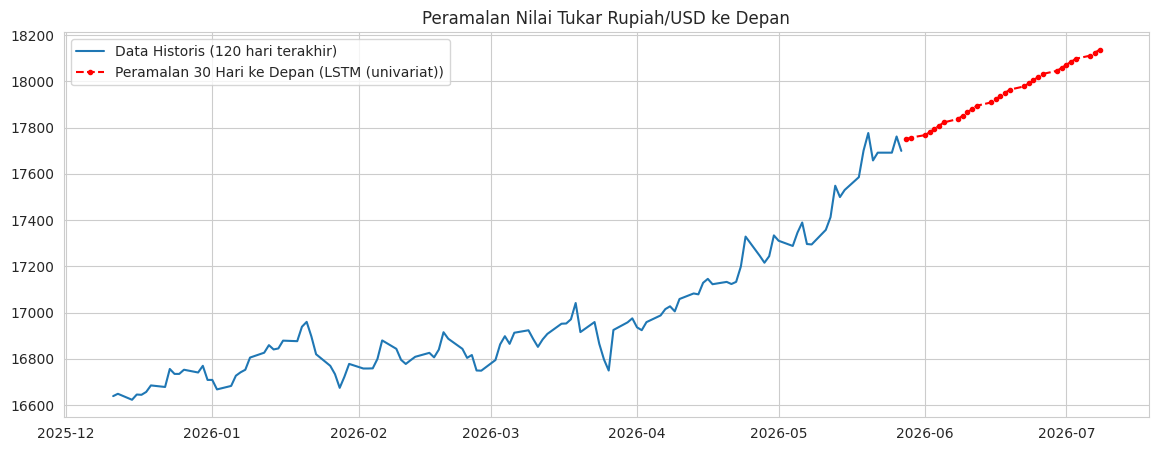

,Ramalan_USD_IDR
2026-05-28,17750.0
2026-05-29,17757.0
2026-06-01,17768.0
2026-06-02,17780.0
2026-06-03,17794.0
2026-06-04,17808.0
2026-06-05,17823.0
2026-06-08,17838.0
2026-06-09,17852.0
2026-06-10,17867.0


In [32]:
FORECAST_DAYS = 30  # jumlah hari bursa ke depan yang ingin diramalkan
best_model_name = comparison_full.iloc[0]["Model"]
future_dates = pd.bdate_range(start=df.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

if best_model_name.startswith("ARIMA"):
    final_model = ARIMA(df[target], order=best_order).fit()
    future_forecast = final_model.forecast(steps=FORECAST_DAYS)
    future_forecast.index = future_dates

else:
    # Refit LSTM univariat terbaik pada SELURUH data (train+test), lalu forecast rekursif
    full_scaled_all = scaler.fit_transform(df[[target]])
    X_all, y_all = create_sequences(full_scaled_all, LOOKBACK)
    X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

    final_lstm = Sequential([
        LSTM(64, activation="tanh", return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        LSTM(32, activation="tanh"),
        Dropout(0.2),
        Dense(1)
    ])
    final_lstm.compile(optimizer="adam", loss="mse")
    final_lstm.fit(X_all, y_all, epochs=100, batch_size=32,
                    callbacks=[EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)],
                    verbose=0)

    window = full_scaled_all[-LOOKBACK:].reshape(1, LOOKBACK, 1)
    preds_scaled = []
    for _ in range(FORECAST_DAYS):
        next_val = final_lstm.predict(window, verbose=0)[0, 0]
        preds_scaled.append(next_val)
        window = np.append(window[:, 1:, :], [[[next_val]]], axis=1)

    future_forecast = pd.Series(
        scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten(),
        index=future_dates
    )

plt.figure(figsize=(14, 5))
plt.plot(df.index[-120:], df[target][-120:], label="Data Historis (120 hari terakhir)")
plt.plot(future_forecast.index, future_forecast.values,
         label=f"Peramalan {FORECAST_DAYS} Hari ke Depan ({best_model_name})",
         color="red", linestyle="--", marker="o", markersize=3)
plt.legend()
plt.title("Peramalan Nilai Tukar Rupiah/USD ke Depan")
plt.show()

future_forecast_df = future_forecast.round(0).rename("Ramalan_USD_IDR").to_frame()
future_forecast_df

# **Kesimpulan**

In [33]:
print("=" * 70)
print("RINGKASAN PERBANDINGAN MODEL")
print("=" * 70)
print(comparison_full.to_string(index=False))

print(f"\nModel dengan performa TERBAIK (MAPE terkecil pada data uji): "
      f"{comparison_full.iloc[0]['Model']}  (MAPE = {comparison_full.iloc[0]['MAPE (%)']:.2f}%)")

print("\nPedoman interpretasi nilai MAPE (Lewis, 1982):")
print("  < 10%   : peramalan sangat akurat")
print("  10-20%  : peramalan baik")
print("  20-50%  : peramalan layak/cukup")
print("  > 50%   : peramalan tidak akurat")

RINGKASAN PERBANDINGAN MODEL
           Model  MAPE (%)       RMSE        MAE
LSTM (univariat)  0.515501 120.752279  85.583004
  ARIMA(1, 1, 0)  1.868632 388.169295 310.196184

Model dengan performa TERBAIK (MAPE terkecil pada data uji): LSTM (univariat)  (MAPE = 0.52%)

Pedoman interpretasi nilai MAPE (Lewis, 1982):
  < 10%   : peramalan sangat akurat
  10-20%  : peramalan baik
  20-50%  : peramalan layak/cukup
  > 50%   : peramalan tidak akurat


# **Implementasi Dashboard**

In [34]:
# ============================================================
# EKSPOR DATA UNTUK DASHBOARD STREAMLIT
# (Tidak mengubah variabel/pipeline di atas — hanya membaca & menyimpan)
# ============================================================
import os
import pandas as pd
import numpy as np

os.makedirs("dashboard_data", exist_ok=True)

# 1) Data aktual historis (USD_IDR)
df_hist_export = df.reset_index()[["Date", target]].copy()
df_hist_export.to_csv("dashboard_data/dashboard_actual.csv", index=False)

# 2) Prediksi ARIMA & LSTM pada periode data uji
df_test_export = pd.DataFrame({"Date": test.index})
df_test_export["ARIMA"] = arima_forecast.values

lstm_pred_full = pd.Series(index=test.index, dtype=float)
lstm_pred_full.iloc[:len(y_pred_lstm)] = y_pred_lstm
df_test_export["LSTM"] = lstm_pred_full.values

df_test_export.to_csv("dashboard_data/dashboard_test_predictions.csv", index=False)

# 3) Peramalan ke depan (future forecast)
df_future_export = pd.DataFrame({
    "Date": future_forecast.index,
    "Forecast": future_forecast.values
})
df_future_export.to_csv("dashboard_data/dashboard_future_forecast.csv", index=False)

# 4) Tabel perbandingan model
comparison_full.to_csv("dashboard_data/dashboard_model_comparison.csv", index=False)

# 5) Metadata (nama model terbaik, order ARIMA terbaik, dsb.)
meta = pd.DataFrame([{
    "best_order": str(best_order),
    "best_model_name": comparison_full.iloc[0]["Model"],
}])
meta.to_csv("dashboard_data/dashboard_meta.csv", index=False)

print("Data untuk dashboard berhasil diekspor ke folder 'dashboard_data/':")
for f in os.listdir("dashboard_data"):
    print(" -", f)

Data untuk dashboard berhasil diekspor ke folder 'dashboard_data/':
 - dashboard_model_comparison.csv
 - dashboard_actual.csv
 - dashboard_test_predictions.csv
 - dashboard_future_forecast.csv
 - dashboard_meta.csv


In [35]:
%%writefile streamlit_app.py
"""
Dashboard Interaktif — Peramalan Nilai Tukar USD/IDR (ARIMA vs LSTM)
=====================================================================
Cara menjalankan:
    1. Pastikan folder `dashboard_data/` (hasil ekspor dari notebook SKRIPSI)
       berada satu direktori dengan file ini.
    2. Install dependensi:
           pip install streamlit plotly pandas
    3. Jalankan:
           streamlit run streamlit_app.py
"""

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import streamlit as st

# --------------------------------------------------------------------------
# KONFIGURASI HALAMAN
# --------------------------------------------------------------------------
st.set_page_config(
    page_title="Dashboard Prediksi Kurs USD/IDR",
    page_icon="📈",
    layout="wide",
)

DATA_DIR = "dashboard_data"


# --------------------------------------------------------------------------
# LOAD DATA (hasil ekspor dari notebook, tidak mengubah pipeline aslinya)
# --------------------------------------------------------------------------
@st.cache_data
def load_data():
    df_hist = pd.read_csv(f"{DATA_DIR}/dashboard_actual.csv", parse_dates=["Date"])
    df_test = pd.read_csv(f"{DATA_DIR}/dashboard_test_predictions.csv", parse_dates=["Date"])
    df_future = pd.read_csv(f"{DATA_DIR}/dashboard_future_forecast.csv", parse_dates=["Date"])
    df_compare = pd.read_csv(f"{DATA_DIR}/dashboard_model_comparison.csv")
    meta = pd.read_csv(f"{DATA_DIR}/dashboard_meta.csv").iloc[0]
    return df_hist, df_test, df_future, df_compare, meta


try:
    df_hist, df_test, df_future, df_compare, meta = load_data()
except FileNotFoundError:
    st.error(
        "File data belum ditemukan. Jalankan seluruh sel di notebook `SKRIPSI.ipynb` "
        "(termasuk sel ekspor data dashboard di bagian paling akhir) terlebih dahulu, "
        "lalu pastikan folder `dashboard_data/` berada di direktori yang sama dengan "
        "`streamlit_app.py` ini."
    )
    st.stop()

best_order = meta["best_order"]
best_model_name = meta["best_model_name"]


# --------------------------------------------------------------------------
# HEADER
# --------------------------------------------------------------------------
st.title("📈 Dashboard Peramalan Kurs USD/IDR")
st.caption("Perbandingan Model ARIMA vs LSTM")

min_date = df_hist["Date"].min().date()
max_date = df_future["Date"].max().date()

# --------------------------------------------------------------------------
# SIDEBAR — KONTROL INTERAKTIF
# --------------------------------------------------------------------------
st.sidebar.header("⚙️ Pengaturan Tampilan")

default_start = max(min_date, (df_hist["Date"].max() - pd.Timedelta(days=180)).date())
date_range = st.sidebar.date_input(
    "Rentang tanggal grafik",
    value=(default_start, max_date),
    min_value=min_date,
    max_value=max_date,
)

if isinstance(date_range, tuple) and len(date_range) == 2:
    start_d, end_d = date_range
else:
    start_d, end_d = min_date, max_date

st.sidebar.markdown("**Tampilkan garis:**")
show_actual = st.sidebar.checkbox("Data Aktual", value=True)
show_arima = st.sidebar.checkbox("Prediksi ARIMA (data uji)", value=True)
show_lstm = st.sidebar.checkbox("Prediksi LSTM (data uji)", value=True)
show_future = st.sidebar.checkbox("Peramalan ke Depan", value=True)

st.sidebar.markdown("---")
st.sidebar.subheader("🔎 Cek Nilai pada Tanggal Tertentu")
selected_date = st.sidebar.date_input(
    "Pilih tanggal",
    value=max_date,
    min_value=min_date,
    max_value=max_date,
)

st.sidebar.markdown("---")
st.sidebar.subheader("🏆 Model Terbaik")
st.sidebar.success(f"{best_model_name}\n\nMAPE terkecil pada data uji")


# --------------------------------------------------------------------------
# FILTER DATA SESUAI RENTANG TANGGAL
# --------------------------------------------------------------------------
def filter_range(df):
    return df[(df["Date"].dt.date >= start_d) & (df["Date"].dt.date <= end_d)]


hist_f = filter_range(df_hist)
test_f = filter_range(df_test)
future_f = filter_range(df_future)


# --------------------------------------------------------------------------
# GRAFIK UTAMA (interaktif — zoom, hover, pan)
# --------------------------------------------------------------------------
fig = go.Figure()

if show_actual:
    fig.add_trace(go.Scatter(
        x=hist_f["Date"], y=hist_f["USD_IDR"],
        name="Aktual", line=dict(color="black", width=2),
    ))
if show_arima:
    fig.add_trace(go.Scatter(
        x=test_f["Date"], y=test_f["ARIMA"],
        name=f"ARIMA{best_order}", line=dict(color="orange", width=2, dash="dash"),
    ))
if show_lstm:
    fig.add_trace(go.Scatter(
        x=test_f["Date"], y=test_f["LSTM"],
        name="LSTM (univariat)", line=dict(color="green", width=2, dash="dash"),
    ))
if show_future:
    fig.add_trace(go.Scatter(
        x=future_f["Date"], y=future_f["Forecast"],
        name="Peramalan ke Depan", line=dict(color="red", width=2, dash="dot"),
        mode="lines+markers", marker=dict(size=4),
    ))

sel_ts = pd.Timestamp(selected_date)
if start_d <= selected_date <= end_d:
    fig.add_vline(x=sel_ts, line_width=1, line_dash="dot", line_color="gray")

fig.update_layout(
    height=520,
    xaxis_title="Tanggal",
    yaxis_title="Kurs USD/IDR",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=10, r=10, t=30, b=10),
)

st.plotly_chart(fig, use_container_width=True)


# --------------------------------------------------------------------------
# NILAI PADA TANGGAL TERPILIH (mencari tanggal bursa terdekat)
# --------------------------------------------------------------------------
st.subheader(f"📅 Detail Nilai — {selected_date.strftime('%d %B %Y')}")

all_dates = pd.concat([df_hist["Date"], df_test["Date"], df_future["Date"]]).drop_duplicates()
nearest_date = all_dates.iloc[(all_dates - sel_ts).abs().argsort().iloc[0]]

if nearest_date != sel_ts:
    st.caption(
        f"Tanggal {selected_date.strftime('%d %b %Y')} bukan hari bursa / di luar data. "
        f"Menampilkan tanggal terdekat: **{nearest_date.strftime('%d %b %Y')}**."
    )

row_hist = df_hist[df_hist["Date"] == nearest_date]
row_test = df_test[df_test["Date"] == nearest_date]
row_future = df_future[df_future["Date"] == nearest_date]

c1, c2, c3, c4 = st.columns(4)
c1.metric("Aktual", f"{row_hist['USD_IDR'].values[0]:,.0f}" if not row_hist.empty else "—")
c2.metric("Prediksi ARIMA", f"{row_test['ARIMA'].values[0]:,.0f}" if not row_test.empty and not np.isnan(row_test['ARIMA'].values[0]) else "—")
c3.metric("Prediksi LSTM", f"{row_test['LSTM'].values[0]:,.0f}" if not row_test.empty and not np.isnan(row_test['LSTM'].values[0]) else "—")
c4.metric("Peramalan ke Depan", f"{row_future['Forecast'].values[0]:,.0f}" if not row_future.empty else "—")


# --------------------------------------------------------------------------
# TABEL PERBANDINGAN MODEL
# --------------------------------------------------------------------------
st.subheader("🏆 Perbandingan Performa Model (Data Uji)")
st.dataframe(df_compare, use_container_width=True, hide_index=True)

st.caption(
    "Pedoman interpretasi MAPE (Lewis, 1982): <10% sangat akurat · 10–20% baik · "
    "20–50% layak/cukup · >50% tidak akurat."
)

# --------------------------------------------------------------------------
# DATA MENTAH (opsional, bisa dilihat & diunduh)
# --------------------------------------------------------------------------
with st.expander("📄 Lihat data mentah pada rentang tanggal terpilih"):
    tab1, tab2, tab3 = st.tabs(["Aktual", "Prediksi Data Uji", "Peramalan ke Depan"])
    with tab1:
        st.dataframe(hist_f, use_container_width=True, hide_index=True)
    with tab2:
        st.dataframe(test_f, use_container_width=True, hide_index=True)
    with tab3:
        st.dataframe(future_f, use_container_width=True, hide_index=True)

Writing streamlit_app.py


In [36]:
# Install Streamlit (sekali saja)
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 82.1 MB/s eta 0:00:00


In [37]:
# Jalankan Streamlit di background, lalu tampilkan lewat proxy port bawaan Colab
import subprocess, time
from google.colab import output

# Matikan proses streamlit lama (jika ada) agar tidak bentrok port
!pkill -f "streamlit run" 2>/dev/null

proc = subprocess.Popen([
    "streamlit", "run", "streamlit_app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false",
], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

time.sleep(8)  # beri waktu Streamlit untuk start

# Buka dashboard di tab/jendela baru lewat proxy Colab (paling stabil, tanpa error dynamic import)
output.serve_kernel_port_as_window(8501)

^C
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>